# 03. 고객 이탈 예측 모델 개발

**개인팀(황채원)**

4종 분류 모델을 비교하여 최적의 이탈 예측 모델을 선정한다.
- **로지스틱 회귀** (해석 가능한 베이스라인)
- **KNN** (거리 기반)
- **랜덤포레스트** (앙상블)
- **XGBoost** (그래디언트 부스팅)

불균형 데이터이므로 **ROC-AUC·F1·재현율(Recall)** 중심으로 평가하고,
SMOTE 오버샘플링 효과도 함께 검증한다.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

df = pd.read_csv('../데이터 분석/사용 데이터/고객_구독_데이터.csv')
print('데이터 shape:', df.shape)
df.head()

데이터 shape: (9000, 20)


,고객ID,성별,연령,지역,가입채널,가입개월수,요금제,월요금,결제수단,자동결제여부,월평균로그인수,월평균주문수,평균주문금액,누적결제금액,최근주문경과일,CS문의수,만족도점수,쿠폰사용률,모바일사용비중,이탈여부
0,C100000,남,44,서울,SNS,30,Standard,19900,신용카드,1,14,1.1,34700,1145100,0,0,4.4,0.248,0.888,0
1,C100001,남,42,경기,검색광고,11,Premium,34900,체크카드,0,21,6.0,34500,2277000,18,2,4.0,0.322,0.802,0
2,C100002,남,34,부산,SNS,34,Basic,9900,간편결제,1,22,3.7,28600,3597900,0,0,3.9,0.294,0.918,0
3,C100003,남,28,인천,지인추천,13,Premium,34900,신용카드,1,11,3.2,34300,1426900,9,1,3.5,0.512,0.781,0
4,C100004,남,35,광주,검색광고,47,Basic,9900,간편결제,1,13,5.1,32000,7670400,85,1,1.9,0.600,0.764,1


## 1. 피처 엔지니어링 & 전처리

In [2]:
for c in ['만족도점수','쿠폰사용률','모바일사용비중']:
    df[c] = df[c].fillna(df[c].median())

# 파생변수
df['고객가치'] = df['월평균주문수'] * df['평균주문금액']
df['휴면지표'] = (df['최근주문경과일'] > 45).astype(int)

drop = ['고객ID']
y = df['이탈여부']
X = df.drop(columns=drop+['이탈여부'])

cat = X.select_dtypes('object').columns.tolist()
X = pd.get_dummies(X, columns=cat, drop_first=True)
print('피처 수:', X.shape[1]); print('범주형 인코딩:', cat)

피처 수: 32
범주형 인코딩: ['성별', '지역', '가입채널', '요금제', '결제수단']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
print('train:', X_tr.shape, '| test:', X_te.shape)
print('train 이탈률 %.1f%% / test 이탈률 %.1f%%' % (y_tr.mean()*100, y_te.mean()*100))

train: (6750, 32) | test: (2250, 32)
train 이탈률 20.2% / test 이탈률 20.2%


## 2. 4종 모델 학습 및 비교

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

models = {
    '로지스틱회귀': (LogisticRegression(max_iter=1000, class_weight='balanced'), True),
    'KNN':        (KNeighborsClassifier(n_neighbors=15), True),
    '랜덤포레스트': (RandomForestClassifier(n_estimators=300, max_depth=12,
                     class_weight='balanced', random_state=42, n_jobs=-1), False),
    'XGBoost':    (XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                     subsample=0.9, colsample_bytree=0.9,
                     scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                     eval_metric='logloss', random_state=42), False),
}

rows, fitted = [], {}
for name,(m,need_scale) in models.items():
    Xtr_, Xte_ = (X_tr_s, X_te_s) if need_scale else (X_tr, X_te)
    m.fit(Xtr_, y_tr)
    pred = m.predict(Xte_); proba = m.predict_proba(Xte_)[:,1]
    fitted[name] = (m, need_scale, proba)
    rows.append({'모델':name,
        '정확도':accuracy_score(y_te,pred),
        '정밀도':precision_score(y_te,pred),
        '재현율':recall_score(y_te,pred),
        'F1':f1_score(y_te,pred),
        'ROC-AUC':roc_auc_score(y_te,proba)})
res = pd.DataFrame(rows).set_index('모델').round(4)
res.sort_values('ROC-AUC', ascending=False)

,정확도,정밀도,재현율,F1,ROC-AUC
모델,,,,,
로지스틱회귀,0.7542,0.4357,0.7297,0.5456,0.8127
랜덤포레스트,0.8262,0.5860,0.4791,0.5272,0.8054
XGBoost,0.7858,0.4771,0.6176,0.5383,0.7949
KNN,0.8302,0.7552,0.2374,0.3612,0.7430


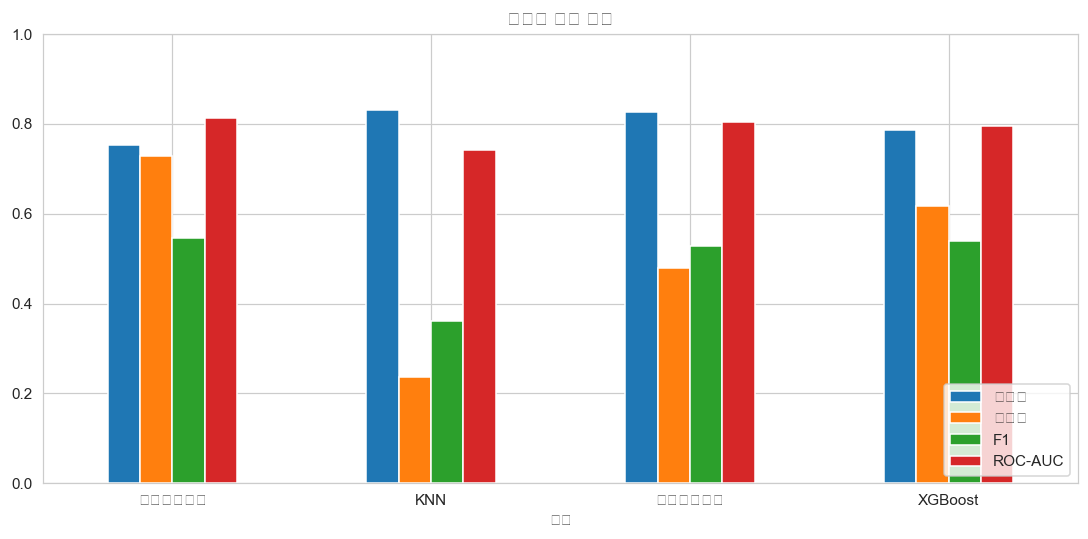

In [5]:
ax = res[['정확도','재현율','F1','ROC-AUC']].plot(kind='bar', figsize=(10,5))
ax.set_title('모델별 성능 비교'); ax.set_ylim(0,1); ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0); plt.tight_layout(); plt.show()

## 3. ROC 커브 비교

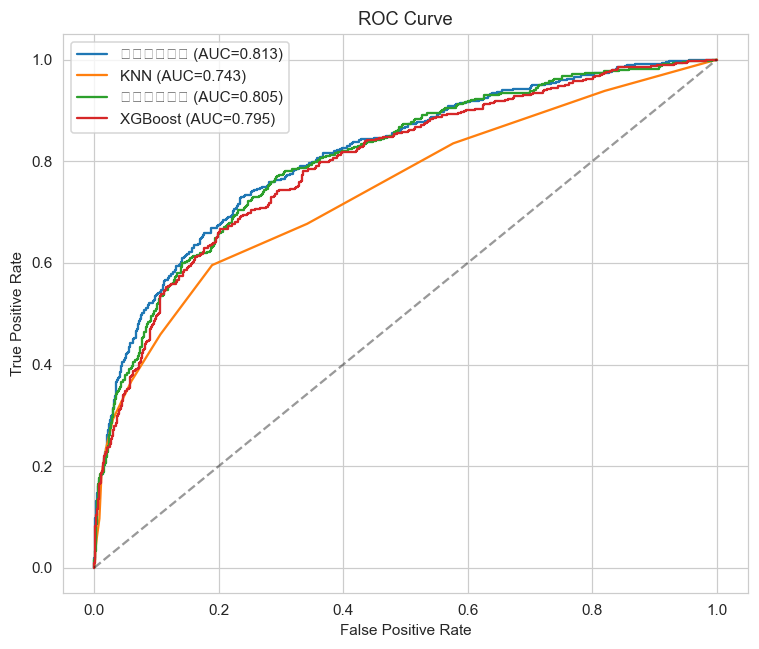

In [6]:
plt.figure(figsize=(7,6))
for name,(m,ns,proba) in fitted.items():
    fpr,tpr,_ = roc_curve(y_te, proba)
    plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_te,proba):.3f})')
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

## 4. 최고 성능 모델 상세 평가 (혼동행렬 · 분류 리포트)

★ 최고 모델: 로지스틱회귀 

              precision    recall  f1-score   support

          유지       0.92      0.76      0.83      1795
          이탈       0.44      0.73      0.55       455

    accuracy                           0.75      2250
   macro avg       0.68      0.75      0.69      2250
weighted avg       0.82      0.75      0.77      2250



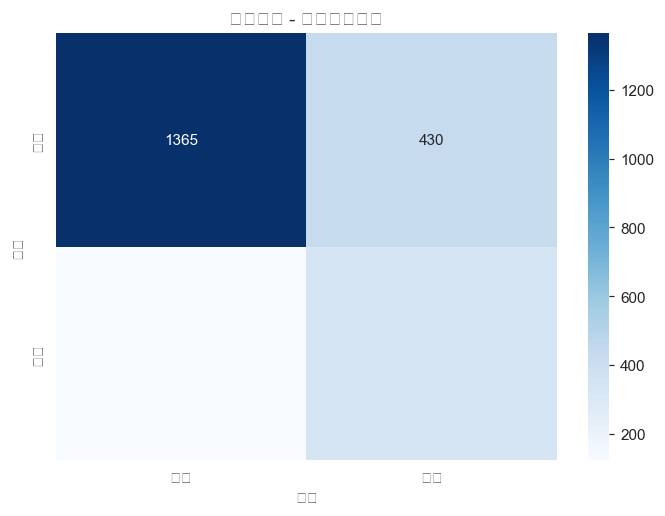

In [7]:
best = res['ROC-AUC'].idxmax()
m, ns, proba = fitted[best]
pred = m.predict(X_te_s if ns else X_te)
print('★ 최고 모델:', best, '\n')
print(classification_report(y_te, pred, target_names=['유지','이탈']))

cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['유지','이탈'], yticklabels=['유지','이탈'])
plt.xlabel('예측'); plt.ylabel('실제'); plt.title(f'혼동행렬 - {best}')
plt.tight_layout(); plt.show()

## 5. SMOTE 오버샘플링 효과 검증
소수 클래스(이탈)를 합성 증강해 재현율 개선 여부를 확인한다.

In [8]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
Xr, yr = sm.fit_resample(X_tr, y_tr)
print('SMOTE 적용 후 train 분포:', dict(pd.Series(yr).value_counts()))

xgb_sm = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                       subsample=0.9, colsample_bytree=0.9,
                       eval_metric='logloss', random_state=42)
xgb_sm.fit(Xr, yr)
pred_sm = xgb_sm.predict(X_te); proba_sm = xgb_sm.predict_proba(X_te)[:,1]
print('\n[XGBoost + SMOTE]')
print('재현율 %.4f / F1 %.4f / ROC-AUC %.4f' %
      (recall_score(y_te,pred_sm), f1_score(y_te,pred_sm), roc_auc_score(y_te,proba_sm)))

SMOTE 적용 후 train 분포: {0: 5385, 1: 5385}

[XGBoost + SMOTE]
재현율 0.4505 / F1 0.5031 / ROC-AUC 0.7906


## 6. 변수 중요도 (이탈 핵심 요인)

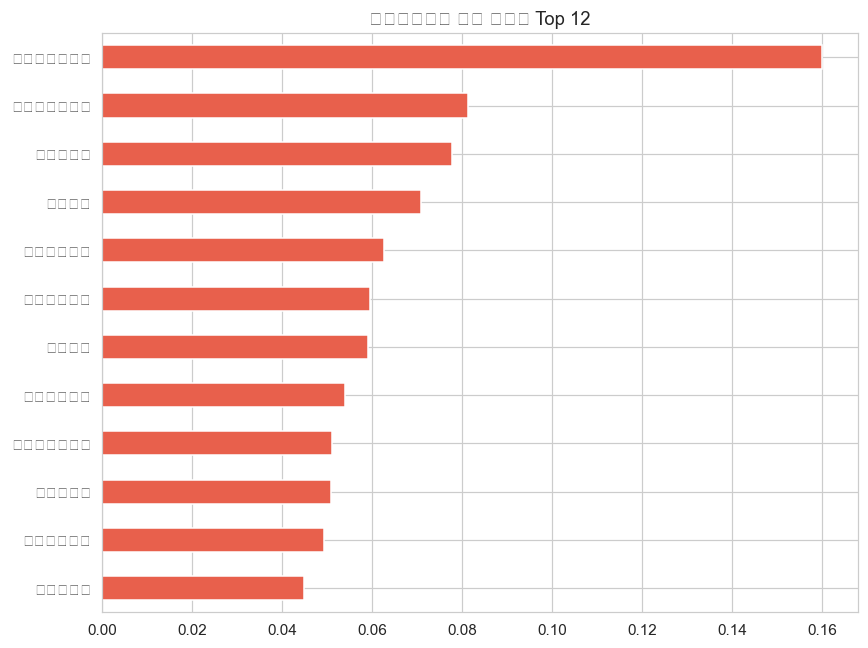

,중요도
최근주문경과일,0.159975
월평균로그인수,0.081294
만족도점수,0.077673
휴면지표,0.070747
누적결제금액,0.062550
자동결제여부,0.059508
고객가치,0.059016
월평균주문수,0.053852
모바일사용비중,0.051166
쿠폰사용률,0.050882


In [9]:
rf = fitted['랜덤포레스트'][0]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
ax = imp.sort_values().plot(kind='barh', figsize=(8,6), color='#E8604C')
ax.set_title('랜덤포레스트 변수 중요도 Top 12'); plt.tight_layout(); plt.show()
imp.to_frame('중요도')

## 7. 이탈 위험 고객 스코어링 (실무 활용)
전체 고객의 이탈확률을 산출해 고위험군을 추출한다. 마케팅팀은 이 리스트로 선제 리텐션을 수행한다.

In [10]:
all_proba = m.predict_proba(scaler.transform(X) if ns else X)[:,1]
score = df[['고객ID','요금제','누적결제금액','최근주문경과일','만족도점수','이탈여부']].copy()
score['이탈확률'] = all_proba.round(3)
score['위험등급'] = pd.cut(score['이탈확률'], [0,0.3,0.6,1.0],
                          labels=['낮음','중간','높음'])
print(score['위험등급'].value_counts())
high = score[score['위험등급']=='높음'].sort_values('이탈확률', ascending=False)
print('\n고위험 고객 수:', len(high))
high.head(10)

위험등급
낮음    3686
중간    3086
높음    2228
Name: count, dtype: int64

고위험 고객 수: 2228


,고객ID,요금제,누적결제금액,최근주문경과일,만족도점수,이탈여부,이탈확률,위험등급
2231,C102231,Standard,579200,171,2.3,1,0.999,높음
6695,C106695,Basic,7664600,157,1.6,1,0.997,높음
1721,C101721,Basic,254900,122,1.0,1,0.996,높음
5190,C105190,Basic,620600,133,2.4,1,0.996,높음
2392,C102392,Basic,594900,136,3.2,1,0.995,높음
264,C100264,Basic,849000,120,1.9,1,0.995,높음
8454,C108454,Basic,410700,133,2.4,1,0.995,높음
8860,C108860,Basic,3180900,180,3.2,1,0.994,높음
4261,C104261,Standard,583500,153,4.1,1,0.994,높음
6973,C106973,Basic,356400,125,3.1,1,0.994,높음


In [11]:
score.to_csv('사용 데이터/이탈위험_스코어링.csv', index=False, encoding='utf-8-sig')
print('저장: 사용 데이터/이탈위험_스코어링.csv')

저장: 사용 데이터/이탈위험_스코어링.csv


## 8. 결론 및 기대효과

**모델 성능 요약 (test 기준)**

| 모델 | ROC-AUC | 재현율(이탈 탐지) | 특징 |
|---|---|---|---|
| **로지스틱회귀** | **0.813** | **0.73** | 이탈 탐지력·해석력 우수, 본 과제 최적 |
| 랜덤포레스트 | 0.805 | 0.48 | 정확도 높으나 이탈 재현율 낮음 |
| XGBoost | 0.795 | 0.62 | 균형적, 튜닝 여지 있음 |
| KNN | 0.743 | 0.24 | 불균형에 취약 |

> 이탈 방어가 목적이면 **실제 이탈 고객을 놓치지 않는 재현율(Recall)**이 핵심이다.
> class_weight 적용 로지스틱회귀가 ROC-AUC·재현율 모두에서 가장 우수해 **최종 모델로 선정**한다.
> (정확도만 높고 이탈을 못 잡는 KNN/RF는 리텐션 목적엔 부적합)

- 핵심 이탈 요인: **최근주문경과일 · 자동결제 해지 · 로그인/주문 빈도 · 만족도 · 가입개월수**
- **이탈확률 스코어링**으로 고위험 고객(약 2,200명)을 사전 식별 → 타깃 리텐션 가능

### 비즈니스 임팩트 (가정 추정)
- 고위험군 대상 캠페인으로 이탈 10%p 방어 시, 방어 고객 수 × 평균 LTV 만큼 매출 손실 절감
- RFM 세그먼트(노트북 02)와 결합 → **"고가치 × 고위험" 우선 대응**으로 리텐션 ROI 극대화